In [325]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sadaaizaz/placement/placement.csv


# Steps

0. Preprocess + EDA + Feature Selection
1. Extract input and output cols
2. Scale the values
3. Train test split
4. Train the model
5. Evaluate the model/model selection
6. Deploy the model

In [326]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pickle

In [327]:
df = pd.read_csv('/kaggle/input/datasets/sadaaizaz/placement/placement.csv')

In [328]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [329]:
df.shape

(100, 4)

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [331]:
df = df.iloc[:,1:]

In [332]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


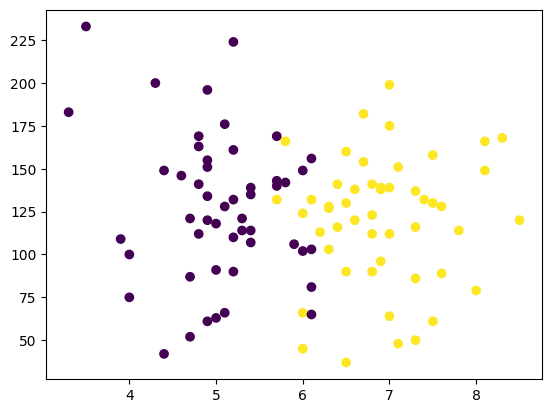

In [333]:
plt.scatter(df['cgpa'], df['iq'], c = df['placement'])

In [334]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [335]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [336]:
y.shape

(100,)

In [337]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [338]:
X_train

,cgpa,iq
17,3.3,183.0
48,6.6,138.0
58,8.0,79.0
45,6.0,66.0
0,6.8,123.0
...,...,...
2,5.3,121.0
6,5.7,143.0
84,5.7,169.0
67,5.0,118.0


In [339]:
y_train

17    0
48    1
58    1
45    1
0     1
     ..
2     0
6     0
84    0
67    0
19    0
Name: placement, Length: 90, dtype: int64

In [340]:
scaler = StandardScaler()

In [341]:
X_train = scaler.fit_transform(X_train)

In [342]:
X_train

array([[-2.36729585,  1.46141849],
       [ 0.51066922,  0.32712472],
       [ 1.7316241 , -1.16006044],
       [-0.01259715, -1.48774531],
       [ 0.68509135, -0.0509732 ],
       [ 0.3362471 ,  0.40274431],
       [-0.53586353,  0.35233125],
       [ 0.77230241,  0.32712472],
       [-0.88470778, -0.85758211],
       [ 0.68509135,  0.40274431],
       [ 0.24903604, -0.55510377],
       [-0.27423034,  0.17588555],
       [ 0.3362471 , -0.2274189 ],
       [-0.18701928,  0.42795084],
       [ 0.94672454,  0.65480959],
       [ 1.99325729,  1.08332057],
       [ 0.16182497, -0.30303848],
       [ 0.85951348, -0.32824501],
       [-1.05912991,  0.95728793],
       [-1.49518522,  1.88992947],
       [-1.23355203,  0.52877695],
       [-0.97191885, -1.61377795],
       [ 0.68509135, -0.88278863],
       [ 1.12114666,  0.30191819],
       [ 0.24903604,  0.04985291],
       [-0.01259715, -0.02576667],
       [ 0.85951348,  1.86472295],
       [-0.79749672, -1.48774531],
       [-0.71028566,

In [343]:
X_test = scaler.transform(X_test)

In [344]:
X_test

array([[-0.97191885,  0.65480959],
       [-0.01259715, -0.58031029],
       [ 1.20835773,  0.17588555],
       [-1.14634097, -1.84063671],
       [ 0.07461391, -1.10964739],
       [-0.18701928,  1.03290751],
       [-1.84402947, -0.4038646 ],
       [ 0.94672454, -1.94146282],
       [-0.53586353,  0.25150514],
       [ 0.42345816,  0.1254725 ]])

In [345]:
clf = LogisticRegression()

In [346]:
#training the model
clf.fit(X_train, y_train)

LogisticRegression()

In [347]:
y_pred = clf.predict(X_test)

In [348]:
y_test

89    0
62    0
3     1
94    0
78    0
85    1
31    0
5     1
49    0
57    1
Name: placement, dtype: int64

In [349]:
accuracy_score(y_test, y_pred)

0.7

<Axes: >

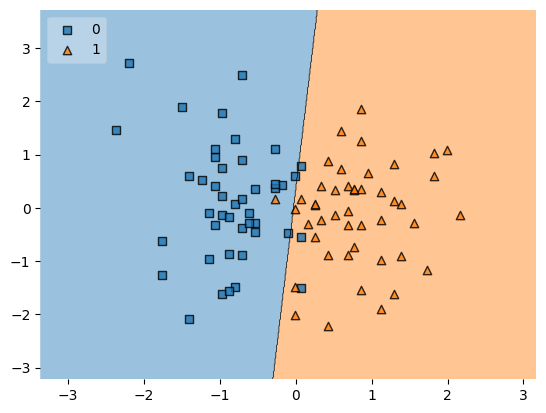

In [350]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train.values, clf = clf, legend = 2)

In [351]:
pickle.dump(clf, open('model.pkl', 'wb'))